In [7]:
# https://www.ercot.com/files/docs/2009/05/20/modelingguidelines_v06.pdf

In [28]:
import pandas as pd
from modo_energy_client.modo_energy_api_client import ModoEnergyAPIClient
from datetime import date
import numpy as np
from scipy.stats.mstats import winsorize
import statsmodels.formula.api as smf

In [2]:
client = ModoEnergyAPIClient(cache_requests=True)

In [4]:
prices = client.get_ercot_prices(date(2024, 7, 1), date(2026, 5, 31))

Fetching pages : 26page [00:00, 27.48page/s]


In [6]:
hb_bus_avg_price = prices[prices["settlementPointName"] == "HB_HOUSTON"][
    "settlementPointPrice"
].astype(int)

In [7]:
hb_bus_avg_price_winsorized = pd.DataFrame(
    {hb_bus_avg_price.name: winsorize(hb_bus_avg_price, limits=[None, 0.01])},
    index=hb_bus_avg_price.index,
)

In [9]:
arbitrage_opportunity = (
    hb_bus_avg_price_winsorized.resample("D")
    .agg(lambda d: d[d.index.hour == 19].item() - d[d.index.hour == 12].item())
    .rename(columns={"settlementPointPrice": "arbitrage_opportunity"})
).astype(int)


<Axes: xlabel='deliveryDate'>

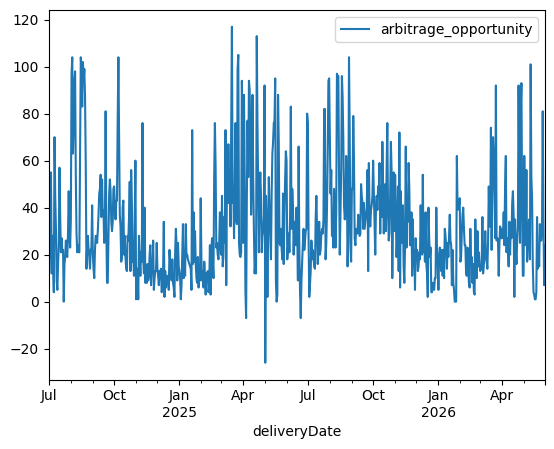

In [10]:
arbitrage_opportunity.plot()

In [23]:
arbitrage_opportunity

,arbitrage_opportunity
deliveryDate,
2024-07-01,12
2024-07-02,21
2024-07-03,19
2024-07-04,55
2024-07-05,12
...,...
2026-05-27,32
2026-05-28,81
2026-05-29,35


In [33]:
arbitrage_opportunity.index.day_of_week

Index([0, 1, 2, 3, 4, 5, 6, 0, 1, 2,
       ...
       4, 5, 6, 0, 1, 2, 3, 4, 5, 6],
      dtype='int32', name='deliveryDate', length=700)

In [34]:
X = pd.DataFrame(
    {
        "month": arbitrage_opportunity.index.month,
        "day_of_week": arbitrage_opportunity.index.day_of_week,
        "arbitrage_opportunity": arbitrage_opportunity["arbitrage_opportunity"],
    },
    index=arbitrage_opportunity.index,
)

In [40]:
model = smf.ols("arbitrage_opportunity ~ C(day_of_week) + C(month)", data=X).fit()

In [50]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                              OLS Regression Results                             
=================================================================================
Dep. Variable:     arbitrage_opportunity   R-squared:                       0.225
Model:                               OLS   Adj. R-squared:                  0.206
Method:                    Least Squares   F-statistic:                     11.65
Date:                   Mon, 15 Jun 2026   Prob (F-statistic):           2.07e-28
Time:                           11:16:07   Log-Likelihood:                -3111.9
No. Observations:                    700   AIC:                             6260.
Df Residuals:                        682   BIC:                             6342.
Df Model:                             17                                         
Covariance Type:               nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept              22.3096      3.304      6.751      0.000      15.821      28.798
C(day_of_week)[T.1]    -0.9179      2.956     -0.311      0.756      -6.722       4.886
C(day_of_week)[T.2]     0.4643      2.958      0.157      0.875      -5.343       6.272
C(day_of_week)[T.3]     0.0948      2.958      0.032      0.974      -5.714       5.903
C(day_of_week)[T.4]    -4.4989      2.959     -1.521      0.129     -10.308       1.310
C(day_of_week)[T.5]    -8.9197      2.958     -3.015      0.003     -14.728      -3.111
C(day_of_week)[T.6]    -1.0892      2.956     -0.368      0.713      -6.893       4.715
C(month)[T.2]           0.1535      3.853      0.040      0.968      -7.412       7.719
C(month)[T.3]          19.7702      3.756      5.264      0.000      12.396      27.145
C(month)[T.4]          21.2708      3.785      5.619      0.000      13.838      28.703
C(month)[T.5]          14.4446      3.754      3.848      0.000       7.074      21.815
C(month)[T.6]          10.9089      4.650      2.346      0.019       1.780      20.038
C(month)[T.7]           9.7992      3.755      2.610      0.009       2.426      17.172
C(month)[T.8]          33.6866      3.754      8.974      0.000      26.316      41.057
C(month)[T.9]          16.5060      3.787      4.359      0.000       9.071      23.941
C(month)[T.10]         19.9038      3.754      5.302      0.000      12.533      27.274
C(month)[T.11]          4.2131      3.785      1.113      0.266      -3.219      11.646
C(month)[T.12]         -3.8839      3.756     -1.034      0.301     -11.258       3.491
==============================================================================
Omnibus:                       87.930   Durbin-Watson:                   1.292
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              122.810
Skew:                           0.911   Prob(JB):                     2.15e-27
Kurtosis:                       3.943   Cond. No.                         13.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<Axes: xlabel='deliveryDate'>

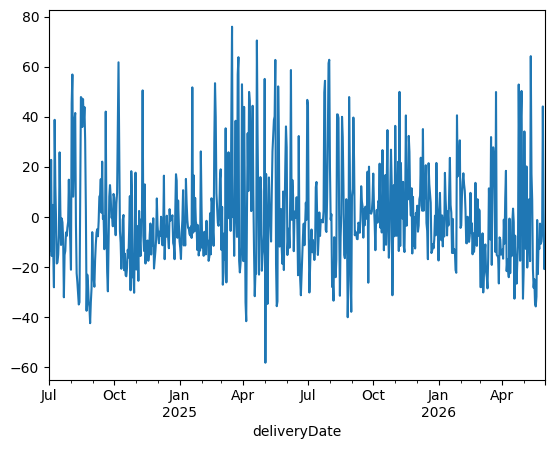

In [52]:
model.resid.plot()

<Axes: xlabel='deliveryDate'>

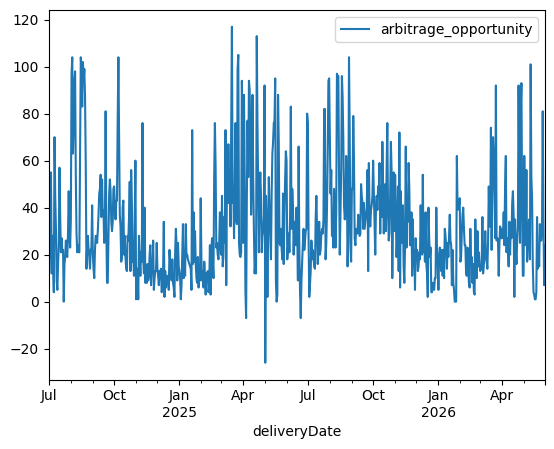

In [45]:
arbitrage_opportunity.plot()